In [76]:
'''
This book joins a csv of players stats from the nfl combines in 1999-2023 to the players stats for all seasons.
The join is done through a weighted system of college, positio, name, and draft year
'''

'\nThis book joins a csv of players stats from the nfl combines in 1999-2023 to the players stats for all seasons.\nThe join is done through a weighted system of college, positio, name, and draft year\n'

In [77]:
import pandas as pd
import numpy as np
import time
import re
from pathlib import Path
from tqdm import tqdm
from urllib.parse import quote_plus
import nflreadpy as nfl
import pandas as pd
from rapidfuzz import process,fuzz
from pprint import pprint
import matplotlib.pyplot as plt
from nameparser import HumanName
import os

In [78]:
# Paths

try:
    main_directory = Path(__file__).parent
except NameError:
    main_directory = Path(os.path.dirname(os.getcwd()))  # fallback for Jupyter

data_folder = main_directory / 'data' # data folder output
notebook_folder = main_directory / 'notebooks' 

In [79]:
def clean(text):
    if pd.isna(text):
        return ""
    else:
        return (str(text).lower().strip())

def standard_name(text):
    np_name = HumanName(text)
    if len(np_name.middle) > 0:
        return f'{np_name.first} {np_name.middle} {np_name.last}'   
    return f'{np_name.first} {np_name.last}'



In [80]:
def fuzz_college(text, comparison_set, threshold=80):
    if pd.isna(text):
        return text
    
    # Find the best match
    result = process.extractOne(text, comparison_set, scorer=fuzz.WRatio)
    if result:
        match, score, index = result
        # If match is good, return the matched name; 
        # otherwise, return the original college
        return match if score >= threshold else text
        
    return text



In [81]:
def score_match(my_row, nfl_row, n_w, p_w, d_w, c_w):

    # Name similarity (0–1)
    name_score = fuzz.ratio(my_row["np_name"], nfl_row["np_name"]) / 100

    # Position match
    position_score = 1.0 if my_row['md_position'] == nfl_row['position'] else 0.0

    # Draft year match
    draft_score = 1.0 if my_row["md_draft_class"] == nfl_row["draft_year"] else 0.0

    # College match
    college_score = 1.0 if (my_row["fuzz_college"] != "" and my_row["fuzz_college"] == nfl_row["college_name"]) else 0.0
    
    # Confidence
    weighted_confidence = n_w * name_score + p_w * position_score +  d_w * draft_score + c_w * college_score
    
    return weighted_confidence

In [82]:
def compare_columns(column_1, column_2):
    col_1_set = set(column_1.dropna().str.strip().str.lower())
    col_2_set = set(column_2.dropna().str.strip().str.lower())

    overlap = col_1_set.intersection(col_2_set)
    missing = col_1_set.difference(col_2_set)

    size_col_1 =  len(column_1)
    count_in_col_2 = column_1.str.strip().str.lower().isin(column_2.str.strip().str.lower()).sum()

    print(f'Column 1 has {len(col_1_set)} unique values. {len(overlap)} exist in Column 2')
    print(f'{count_in_col_2} out of {size_col_1} in Column 1 exist in Column 2\n\n')
    print('Missing Values')
    pprint(missing)
          


In [83]:
def match_player(row, players_names, players_records, n_w, p_w, d_w, c_w, top_k=5 ):

    candidates = process.extract(
        row["np_name"],
        players_names,
        scorer=fuzz.ratio,
        limit=top_k
    )

    best_match = None
    best_score = -1

    for name_match, _, idx in candidates:
        nfl_row = players_records[idx]
        score = score_match(row, nfl_row, n_w, p_w, d_w, c_w)

        if score > best_score:
            best_score = score
            best_match = nfl_row

    return pd.Series({
        "matched_name": best_match["display_name"] if best_match else None,
        "matched_draft_year": best_match["draft_year"] if best_match else None,
        "matched_college": best_match["college_name"] if best_match else None,
        "matched_position": best_match["position"] if best_match else None,
        "nflread_pfr_id" : best_match['pfr_id'] if best_match else None,
        "confidence": best_score
    })

In [84]:

# Load the players crosswalk — has pfr_id, draft year, name, position, college, etc.
players = nfl.load_players().to_pandas()

In [85]:
display(players.columns)

Index(['gsis_id', 'display_name', 'common_first_name', 'first_name',
       'last_name', 'short_name', 'football_name', 'suffix', 'esb_id',
       'nfl_id', 'pfr_id', 'pff_id', 'otc_id', 'espn_id', 'smart_id',
       'birth_date', 'position_group', 'position', 'ngs_position_group',
       'ngs_position', 'height', 'weight', 'headshot', 'college_name',
       'college_conference', 'jersey_number', 'rookie_season', 'last_season',
       'latest_team', 'status', 'ngs_status', 'ngs_status_short_description',
       'years_of_experience', 'pff_position', 'pff_status', 'draft_year',
       'draft_round', 'draft_pick', 'draft_team'],
      dtype='object')

In [86]:
display(players['position'].unique())
display(players['college_name'].unique())

array(['NT', 'RB', 'LB', 'K', 'WR', 'DE', 'S', 'DB', 'FS', 'OLB', 'TE',
       'G', 'CB', 'OT', 'DT', 'C', 'MLB', 'QB', 'LS', 'SAF', 'DL', 'P',
       'ILB', 'OL', 'FB'], dtype=object)

array(['UNLV', 'Pittsburgh', 'Wake Forest', ...,
       'Missouri Western; Nebraska-Omaha',
       'Concordia College; Augustana (SD)',
       'Boise State; Hawaii; Walla Walla Community College'],
      shape=(3743,), dtype=object)

In [87]:
# Read scraped combine data
df_nfl_combine = pd.read_csv(data_folder/"nfl_combine_data.csv")
df = df_nfl_combine.copy()
df.shape


(8707, 20)

In [88]:
df.columns

Index(['md_player_name', 'md_player_id', 'md_url', 'md_draft_class',
       'md_position', 'md_college', 'md_weight_lbs', 'md_height_in',
       'md_arm_length_in', 'md_hand_size_in', 'md_wing_span_in',
       'md_yard_40_dash_sec', 'md_yard_20_split_sec', 'md_yard_60_shuttle_sec',
       'md_yard_10_split_sec', 'md_cone_drill_sec', 'md_yard_20_shuttle_sec',
       'md_vert_jump_in', 'md_broad_jump_in', 'md_bench_press_reps'],
      dtype='object')

In [89]:
print(set(players['college_name'].unique()))

{'', 'East Central; Cisco Junior College; Abilene Christian', 'Northern Illinois; Lafayette College', 'Middle Tennessee State; Dodge City CC', 'Sacramento State; Arizona State; Bakersfield College', 'Arkansas State; Fort Scott CC', 'UMass Amherst; Navy', 'N.C. State; Boise State', 'Central Oklahoma; Oklahoma', 'Ohio State; City College (SF)', 'Marshall; Georgia Military', 'Cal State-Bakersfield', 'Michigan State; Wake Forest', 'Louisiana-Lafayette; TCU', 'University of St. Thomas', 'Indiana PA,  University of; Penn State', 'Portland State; Walla Walla Community College', 'UAB; Middle Georgia College', 'Miami (Ohio); University of Evansville', 'Northwestern; University of Evansville; Illinois', 'Lambuth', 'Berry College', 'USC; San Jose State; San Joaquin Delta College', 'South Carolina; Miami (Ohio)', 'Arizona; Colorado', 'Miami; Houston', 'Iowa; Michigan', 'Utah State; Eastern Arizona', 'Auburn; St. Bernard', 'West Chester State University', 'Emporia State University', 'San Diego Stat

### Columns standardized and filtered

In [90]:

# Strip and clean college names

df['md_college'] = df['md_college'].apply(clean)
players['college_name'] = players['college_name'].apply(clean)

# Strip and clean position names

df['md_position'] = df['md_position'].apply(clean)
players['position'] = players['position'].apply(clean)

# Strip and clean player names
# Remove suffixes

df['md_player_name'] =  df['md_player_name'].apply(clean)
players['display_name'] =  players['display_name'].apply(clean)

### Standardize Colleges in csv

In [91]:
# Find not matching universities/colleges

compare_columns(df['md_college'], players['college_name'])



Column 1 has 361 unique values. 255 exist in Column 2
8166 out of 8707 in Column 1 exist in Column 2


Missing Values
{'albany state',
 'arkansas pine bluff',
 'arkansas-pine bluff',
 'belhaven',
 'bethune-cookman',
 'cal',
 'cal davis',
 'cal poly',
 'catawba',
 'central connecticut state',
 'central florida',
 'central washington',
 'charleston southern',
 'chattanooga',
 'cheyney',
 'citadel',
 'clarion',
 'clark atlanta',
 'colorado state-pueblo',
 'concordia (mn)',
 'concordia-st. paul',
 'culver-stockton',
 'dixie state',
 'ecu',
 'emporia state',
 'fayetteville state',
 'fiu',
 'fort hays state',
 'fort valley state (ga)',
 'grand valley state',
 'gustavus adolphus',
 'harding',
 'hartwick',
 "hawai'i",
 'houston christian',
 'indiana (pa)',
 'jackson state',
 'kentucky state',
 'kutztown (pa)',
 'lafayette',
 'lane',
 'lehigh',
 'lenoir-rhyne',
 'malone university (ohio)',
 'marian (in)',
 'massachusetts',
 'merrimack',
 'miami (oh)',
 'michigan tech',
 'middle tennessee',
 'mi

In [92]:
# Fuzzy match on colleges

unique_df_colleges = df['md_college'].unique().tolist()
players_college_list = list(set(players['college_name'])) # Use for fuzzmatching

mapping = {}
for college in unique_df_colleges:
    if pd.isna(college):
        mapping[college] = college
        continue

    match, score, _ = process.extractOne(
        college,
        players_college_list,
        scorer=fuzz.WRatio
    )

    if score >= 80:
        mapping[college] = match
    else:
        mapping[college] = college

df['fuzz_college'] = df['md_college'].replace(mapping)

In [93]:
# Find not matching universities/colleges
compare_columns(df['fuzz_college'], players['college_name'])


Column 1 has 319 unique values. 311 exist in Column 2
8569 out of 8707 in Column 1 exist in Column 2


Missing Values
{'concordia-st. paul',
 'ecu',
 'fiu',
 'hartwick',
 'massachusetts',
 'ole miss',
 'utep',
 'utsa'}


In [94]:
# drop_colleges = ['belhaven',
#  'cheyney',
#  'concordia-st. paul',
#  'culver-stockton',
#  'dubuque',
#  'ecu',
#  'fiu',
#  'hartwick',
#  'marian (in)',
#  'massachusetts',
#  'merrimack',
#  'ole miss',
#  'stony brook',
#  'tiffin',
#  'utep',
#  'utsa',
#  'whitworth']

# df = df[~df['college'].isin(drop_colleges)]

### Standardize positions

In [95]:
# Standardize positions

print(sorted(list(set(players['position'].unique()))))
print(sorted(list(set(df['md_position'].unique()))))

['c', 'cb', 'db', 'de', 'dl', 'dt', 'fb', 'fs', 'g', 'ilb', 'k', 'lb', 'ls', 'mlb', 'nt', 'ol', 'olb', 'ot', 'p', 'qb', 'rb', 's', 'saf', 'te', 'wr']
['3-4 outside linebacker', 'athlete', 'cornerback', 'defensive back', 'defensive line', 'defensive tackle', 'edge defender', 'fullback', 'halfback', 'inside linebacker', 'interior defensive line', 'kicker', 'linebacker', 'long snapper', 'nose tackle', 'offensive center', 'offensive guard', 'offensive line', 'offensive tackle', 'one-gap defensive end', 'outside linebacker', 'punter', 'quarterback', 'safety', 'tight end', 'wide receiver']


Positions that are not core/standard across all types of schemes will be filtered out. Positions that cannot be aligned across both datasets will be filtered out

Removed
* Edge Defender
* Inside Lineback
* Safety
* Interior Defensive Line
* 3-4 Outside Lineback
* One-gap defensive end
* Athelete

In [96]:
position_map = {
    "offensive center": "c",
    "cornerback": "cb",
    "defensive back": "db",
    "edge defender": "remove",
    "defensive line": "dl",
    "defensive tackle": "dt",
    "fullback": "fb",
    "safety": "remove",
    "offensive guard": "g",
    "inside linebacker": "remove",
    "kicker": "k",
    "linebacker": "lb",
    "long snapper": "ls",
    "offensive line": "ol",
    "outside linebacker": "olb",
    "offensive tackle": "ot",
    "punter" :"p",
    "quarterback": "qb",
    "halfback":"rb",
    "safety": "remove",
    "tight end": "te",
    "wide receiver": "wr",
    "nose tackle": "nt",
    "interior defensive line": "remove",
    "3-4 outside linebacker":"remove",
    "one-gap defensive end": "remove",
    'athlete' : 'remove'
}

In [97]:
df['md_position'] = df['md_position'].apply(clean)
df['md_position'] = df['md_position'].map(position_map).apply(clean).fillna(df['md_position'])
df = df[df['md_position'] != 'remove']

In [98]:
compare_columns(df['md_position'], players['position'])

Column 1 has 19 unique values. 19 exist in Column 2
6944 out of 6944 in Column 1 exist in Column 2


Missing Values
set()


### Standardize Names in CSV for Fuzzy

In [99]:
# df["md_players_with_same_name"] = np.where(df["md_player_name"].map(df["md_player_name"].value_counts()) > 1,
#     "Y",
#     "N")

# df_single_names = df[df["md_players_with_same_name"] == "N"].copy()
# df_multi_names  = df[df["md_players_with_same_name"] == "Y"].copy()

# print(f"Players with no duplicate names:    {len(df_single_names)}")
# print(f"Players with duplicate names: {len(df_multi_names)}")

In [100]:
df['np_name'] = df['md_player_name'].apply(standard_name)
players['np_name'] = players['display_name'].apply(standard_name)

In [101]:
# make lookup easier 

players_records = players.to_dict("records")
players_names = players["np_name"].tolist()

Dataset will be aligned based on position, draft_year, name and college in order of highest weight to lowest  

* Positions - Standard positions, it is rare for players to switch positions. So we place the highest weight on that.
* Draft_year - Players drafted typically have cleaner data
* Name - Not a lot of shared names within our dataset
* College - college can be ambigious so we place the least focus on that


In [102]:
# Condition matching weights
# Weights chosen on what we prioritize + combination of weights do not equal other so we can see what weights are active in the histogram
name_weight  = 13.33
position_weight = 53.33 
draft_weight = 26.67
college_weight = 6.67

In [103]:
results = df[['md_player_name', 'np_name', 'md_player_id', 'md_draft_class','md_position','fuzz_college']].apply(match_player, axis=1, args=(players_names, players_records, name_weight, position_weight, draft_weight, college_weight))
df_matched = pd.concat([df[['md_player_name', 'md_player_id', 'md_draft_class','md_position','fuzz_college']], results], axis=1)

In [104]:
display(df_matched.columns)
display(df_matched.head(50))

Index(['md_player_name', 'md_player_id', 'md_draft_class', 'md_position',
       'fuzz_college', 'matched_name', 'matched_draft_year', 'matched_college',
       'matched_position', 'nflread_pfr_id', 'confidence'],
      dtype='object')

,md_player_name,md_player_id,md_draft_class,md_position,fuzz_college,matched_name,matched_draft_year,matched_college,matched_position,nflread_pfr_id,confidence
0,a'shawn robinson,ashawnrobinson2016,2016,dt,alabama,a'shawn robinson,2016.0,alabama,dt,RobiAS00,100.000000
1,a.c. leonard,acleonard2014,2014,te,tennessee state,matt leonard,NaN,stanford,dt,LeonMa20,9.997500
2,a.j. brown,ajbrown2019,2019,wr,ole miss,a.j. brown,2019.0,mississippi,wr,BrowAJ00,93.330000
3,a.j. cann,ajcann2015,2015,g,south carolina,a.j. cann,2015.0,south carolina,g,CannA.00,100.000000
4,a.j. derby,ajderby2015,2015,te,arkansas,a.j. derby,2015.0,arkansas; coffeyville cc; iowa,te,DerbA.00,93.330000
5,a.j. edds,ajedds2010,2010,olb,iowa,a.j. edds,2010.0,iowa,lb,EddsA.99,46.670000
6,a.j. epenesa,ajepenesa2020,2020,dl,iowa,a.j. epenesa,2020.0,iowa,de,EpenAJ00,46.670000
7,a.j. green,ajgreen2020,2020,cb,oklahoma state,a.j. green,NaN,oklahoma state,cb,GreeAJ00,73.330000
8,a.j. green,ajgreen2011,2011,wr,georgia,a.j. green,2011.0,georgia,wr,GreeA.00,100.000000
9,a.j. greene,ajgreene2012,2012,ot,auburn,a.j. greene,1989.0,wake forest,db,GreeA.20,13.330000


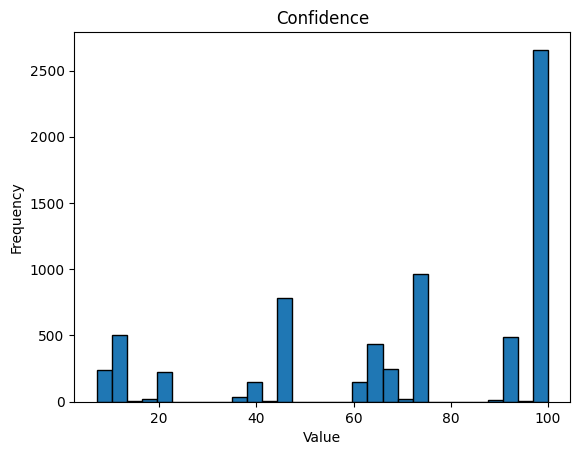

In [105]:
df_matched['confidence'].hist(bins=30, edgecolor='black', grid=False)

plt.title('Confidence')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [106]:
confidence_conditions = [df_matched['confidence'] < 25, 
                        df_matched['confidence'] < 50,
                        df_matched['confidence'] < 75,
                        df_matched['confidence'] < 100]
confidence_results = ['low', 'low-medium', 'medium', 'high']

df_matched['confidence_label'] = np.select(confidence_conditions, confidence_results, default='perfect')

In [107]:
display(df_matched.head())

,md_player_name,md_player_id,md_draft_class,md_position,fuzz_college,matched_name,matched_draft_year,matched_college,matched_position,nflread_pfr_id,confidence,confidence_label
0,a'shawn robinson,ashawnrobinson2016,2016,dt,alabama,a'shawn robinson,2016.0,alabama,dt,RobiAS00,100.0000,perfect
1,a.c. leonard,acleonard2014,2014,te,tennessee state,matt leonard,NaN,stanford,dt,LeonMa20,9.9975,low
2,a.j. brown,ajbrown2019,2019,wr,ole miss,a.j. brown,2019.0,mississippi,wr,BrowAJ00,93.3300,high
3,a.j. cann,ajcann2015,2015,g,south carolina,a.j. cann,2015.0,south carolina,g,CannA.00,100.0000,perfect
4,a.j. derby,ajderby2015,2015,te,arkansas,a.j. derby,2015.0,arkansas; coffeyville cc; iowa,te,DerbA.00,93.3300,high


We only use records that have a high confidence. This dramatically drops our sample size, but our data is still much bigger than data used in other studies

In [108]:
df_matched_filter = df_matched[(df_matched['confidence_label'] == 'high') | (df_matched['confidence_label'] == 'perfect')]
df_matched_filter = df_matched_filter[['md_player_name', 'md_position', 'md_draft_class', 'nflread_pfr_id', 'md_player_id']] # Remove extra columns
# df_final_player_records  = 

In [109]:
display(df_matched_filter.head())

,md_player_name,md_position,md_draft_class,nflread_pfr_id,md_player_id
0,a'shawn robinson,dt,2016,RobiAS00,ashawnrobinson2016
2,a.j. brown,wr,2019,BrowAJ00,ajbrown2019
3,a.j. cann,g,2015,CannA.00,ajcann2015
4,a.j. derby,te,2015,DerbA.00,ajderby2015
8,a.j. green,wr,2011,GreeA.00,ajgreen2011


In [110]:
df_nfl_combine_stats = pd.merge(df_nfl_combine, df_matched_filter, how = 'inner', left_on = ['md_player_id'], right_on = ['md_player_id'])
nfl_combine_columns_to_drop  = [
    'md_player_name_x',
    'md_player_id',
    'md_draft_class_x',
    'md_position_x',
    'md_draft_class_y',
    'md_college',
    'md_url'
]
df_nfl_combine_stats = df_nfl_combine_stats.drop(columns=nfl_combine_columns_to_drop)

nfl_combine_columns_to_rename = {
    'md_player_name_y':'player_name',
    'nflread_pfr_id': 'pfr_id',
    'md_position_y':'position'
}


df_nfl_combine_stats = df_nfl_combine_stats.rename(columns=nfl_combine_columns_to_rename)
df_nfl_combine_stats = df_nfl_combine_stats[['player_name','pfr_id','position','md_weight_lbs','md_height_in','md_arm_length_in', 'md_wing_span_in', 'md_hand_size_in','md_yard_40_dash_sec', 'md_yard_60_shuttle_sec',
                                             'md_yard_10_split_sec','md_yard_20_split_sec', 'md_cone_drill_sec','md_yard_20_shuttle_sec','md_vert_jump_in','md_broad_jump_in','md_bench_press_reps']]
# df_nfl_combine_stats.rename
display(df_nfl_combine_stats.head())
display(df_nfl_combine_stats.columns)


,player_name,pfr_id,position,md_weight_lbs,md_height_in,md_arm_length_in,md_wing_span_in,md_hand_size_in,md_yard_40_dash_sec,md_yard_60_shuttle_sec,md_yard_10_split_sec,md_yard_20_split_sec,md_cone_drill_sec,md_yard_20_shuttle_sec,md_vert_jump_in,md_broad_jump_in,md_bench_press_reps
0,a'shawn robinson,RobiAS00,dt,307.0,72.0,34.500,NaN,10.50,5.20,NaN,1.78,NaN,7.80,4.74,26.0,106.0,22.0
1,a.j. brown,BrowAJ00,wr,226.0,72.0,32.875,78.0,9.75,4.49,NaN,NaN,NaN,NaN,NaN,36.5,120.0,19.0
2,a.j. cann,CannA.00,g,313.0,72.0,32.625,NaN,10.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0
3,a.j. derby,DerbA.00,te,255.0,72.0,30.500,NaN,9.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0
4,a.j. green,GreeA.00,wr,211.0,72.0,34.375,NaN,9.25,4.48,11.46,1.55,2.53,6.91,4.21,34.5,126.0,18.0


Index(['player_name', 'pfr_id', 'position', 'md_weight_lbs', 'md_height_in',
       'md_arm_length_in', 'md_wing_span_in', 'md_hand_size_in',
       'md_yard_40_dash_sec', 'md_yard_60_shuttle_sec', 'md_yard_10_split_sec',
       'md_yard_20_split_sec', 'md_cone_drill_sec', 'md_yard_20_shuttle_sec',
       'md_vert_jump_in', 'md_broad_jump_in', 'md_bench_press_reps'],
      dtype='object')

In [111]:
df_player_stats = df_nfl_combine_stats.copy()

df_player_stats_columns_to_keep  = ['pfr_id']
df_player_stats = df_player_stats[df_player_stats_columns_to_keep]
df_player_stats = pd.merge(df_player_stats, players, how = 'inner', left_on = 'pfr_id', right_on = 'pfr_id', suffixes=['','_y'])

df_player_stats_columns_to_keep.append('gsis_id')
df_player_stats = df_player_stats[df_player_stats_columns_to_keep]
# ['player_name','pfr_id','position']

In [112]:
df_player_stats.head()

,pfr_id,gsis_id
0,RobiAS00,00-0032889
1,BrowAJ00,00-0035676
2,CannA.00,00-0032255
3,DerbA.00,00-0031609
4,GreeA.00,00-0027942


Extract player data from the lowest draft season to 3 years after the highest draft season

In [113]:
min_draft_season = df['md_draft_class'].min()
max_draft_season = df['md_draft_class'].max()
print(min_draft_season)
print(max_draft_season)

1999
2026


In [117]:
frames = []
for season in range(min_draft_season, max_draft_season+1):
    print(f"Loading {season}...")
    try:
        df = nfl.load_player_stats([season]).to_pandas()
        frames.append(df)
        time.sleep(5)
    except ConnectionError as e:
        print(f"Skipping {season}: {e}")

player_stats = pd.concat(frames, ignore_index=True)

Loading 1999...
Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...
Loading 2023...
Loading 2024...
Loading 2025...
Loading 2026...
Skipping 2026: Failed to download https://github.com/nflverse/nflverse-data/releases/download/stats_player/stats_player_week_2026.parquet: 404 Client Error: Not Found for url: https://github.com/nflverse/nflverse-data/releases/download/stats_player/stats_player_week_2026.parquet


In [118]:
df_player_stats = pd.merge(df_player_stats, player_stats, how = 'left', left_on = 'gsis_id', right_on ='player_id', suffixes=['', '_y'])

In [ ]:
display(df_player_stats.head())

,pfr_id,gsis_id,player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,...,pat_blocked_y,pat_pct_y,gwfg_made_y,gwfg_att_y,gwfg_missed_y,gwfg_blocked_y,gwfg_distance_y,fantasy_points_y,fantasy_points_ppr_y,game_id_y
0,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,RobiAS00,00-0032889,00-0032889,A.Robinson,A'Shawn Robinson,DE,DL,https://static.www.nfl.com/image/upload/f_auto...,2016.0,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [ ]:

df_player_stats.to_csv(data_folder/'player_stats.csv',index=False)

In [120]:

df_player_stats.to_parquet(data_folder/'player_stats_parquet.parquet', index=False)